In [31]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
import requests
import warnings
import plotly.express as px
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import time
import json

# prison path from API
download_new_datasets = False

if download_new_datasets:
    # AI adoption API links
    prison_data_link = ("https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/crim_pris_age/1.0/*.*.*.*.*?c[freq]=A&"
                        "c[age]=TOTAL&"
                        "c[sex]=T,M,F&"
                        "c[unit]=NR&"
                        "c[geo]=BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE&"
                        "c[TIME_PERIOD]=2023,2022,2021,2020,2019,2018,2017,2016,2015,2014&compress=false&"
                        "format=csvdata&formatVersion=2.0&"
                        "lang=en&labels=name")

    # Downloading the datasets and saving them as CSV files in the data folder
    prison_data_response = requests.get(prison_data_link)

    with open("../data/prison data/Prison_data.csv", "wb") as f:
        f.write(prison_data_response.content)

# Loading the datasets into pandas DataFrames
prison_data_df = pd.read_csv("../data/prison data/Prison_data.csv")
print(f"Prison Data DataFrame shape: {prison_data_df.shape[0]} rows, {prison_data_df.shape[1]} columns")

Prison Data DataFrame shape: 781 rows, 21 columns


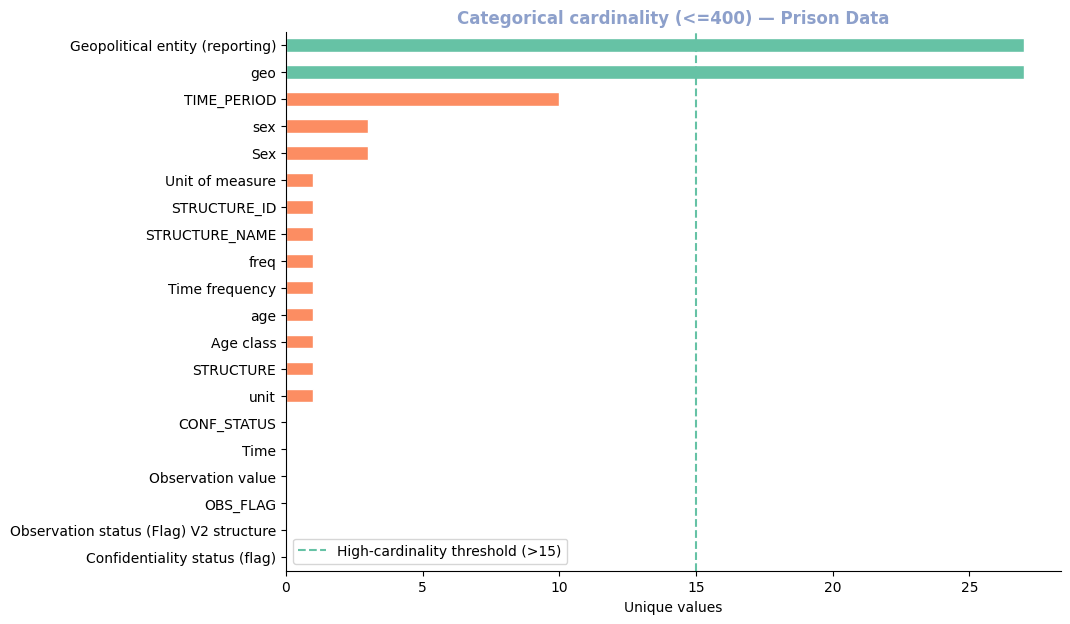

HIGH-CARDINALITY features (excluded from chart):
    'OBS_VALUE': 744 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data):
  'Confidentiality status (flag)' (0 values): []

  'Observation status (Flag) V2 structure' (0 values): []

  'OBS_FLAG' (0 values): []

  'Observation value' (0 values): []

  'Time' (0 values): []

  'CONF_STATUS' (0 values): []

  'unit' (1 values): ['NR']

  'STRUCTURE' (1 values): ['dataflow']

  'Age class' (1 values): ['Total']

  'age' (1 values): ['TOTAL']

  'Time frequency' (1 values): ['Annual']

  'freq' (1 values): ['A']

  'STRUCTURE_NAME' (1 values): ['Prisoners by age and sex']

  'STRUCTURE_ID' (1 values): ['ESTAT:CRIM_PRIS_AGE(1.0)']

  'Unit of measure' (1 values): ['Number']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'sex' (3 values): ['F', 'M', 'T']

  'TIME_PERIOD' (10 values): ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (27 values): ['AT', 'BE', 'BG

In [32]:
# cardinality of the dataset
YEARS = range(2008, 2024)
PALETTE = sns.color_palette("Set2")
CORAL, STEEL, NAVY = PALETTE[0], PALETTE[1], PALETTE[2]
def inspect_categorical(df, dataset_name):
    cat_cols = df.select_dtypes(include=["object", "category", "bool", "int64", "float64"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical cardinality (<=400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique values"); plt.legend(); sns.despine()
        plt.show()

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    '{col}': {val} unique values — needs grouping/target encoding")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(prison_data_df, "Prison Data")

In [33]:
country_codes = {
    "Austria": "AUT", "Belgium": "BEL", "Bulgaria": "BGR", 
    "Croatia": "HRV", "Cyprus": "CYP", "Czechia": "CZE", 
    "Estonia": "EST", "Finland": "FIN", "France": "FRA",
    "Germany": "DEU", "Greece": "GRC", "Hungary": "HUN",
    "Ireland": "IRL", "Italy": "ITA","Denmark": "DNK",
    "Latvia": "LVA", "Romania": "ROU",  "Slovakia": "SVK",
    "Lithuania": "LTU", "Luxembourg": "LUX", "Malta": "MLT",
    "Netherlands": "NLD", "Poland": "POL", "Portugal": "PRT",
    "Slovenia": "SVN", "Spain": "ESP", "Sweden": "SWE",
}
area_km2 = {
    "Albania": 28748, "Austria": 83879, "Belgium": 30689,
    "Bulgaria": 110994, "Croatia": 56594, "Poland": 312696,
    "Cyprus": 9251, "Czechia": 78871, "Denmark": 42952,
    "Estonia": 45339, "Finland": 338455, "France": 643801,
    "Germany": 357596, "Greece": 131957, "Hungary": 93030,
     "Ireland": 70273, "Italy": 302068, "Portugal": 92212,
    "Latvia": 64589, "Switzerland": 41285, "Türkiye": 783562,
    "Lithuania": 65300, "Luxembourg": 2586, "Malta": 316,
    "Romania": 238397, "Slovakia": 49035, "Netherlands": 41865, 
    "Slovenia": 20271, "Spain": 505990, "Sweden": 450295, "EU Average": 10530000
}
# Sessione con retry automatici
session = requests.Session()
retry = Retry(
    total=5,
    backoff_factor=2,                              # attese: 2s, 4s, 8s, 16s, 32s
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=["GET"],
)
session.mount("https://", HTTPAdapter(max_retries=retry))

# Cache su disco — evita di rifare chiamate già riuscite
CACHE_FILE = Path("worldbank_population_cache.json")
if CACHE_FILE.exists():
    with open(CACHE_FILE) as f:
        _cache = json.load(f)
else:
    _cache = {}
def get_population_world_bank(iso3_code, start_year=2008, end_year=2023):
    cache_key = f"{iso3_code}_{start_year}_{end_year}"
    if cache_key in _cache:
        # converti chiavi anno da str (JSON) a int
        return {int(k): v for k, v in _cache[cache_key].items()}
    url = (
        f"https://api.worldbank.org/v2/country/{iso3_code}/indicator/SP.POP.TOTL"
        f"?format=json&date={start_year}:{end_year}&per_page=100"
    )
    try:
        response = session.get(url, timeout=(15, 90))   # (connect, read)
        response.raise_for_status()
        payload = response.json()
        if not isinstance(payload, list) or len(payload) < 2 or payload[1] is None:
            print(f"[warn] nessun dato per {iso3_code}")
            return {}
        result = {
            int(item["date"]): int(item["value"])
            for item in payload[1]
            if item.get("value") is not None
        }
        # salva in cache
        _cache[cache_key] = result
        with open(CACHE_FILE, "w") as f:
            json.dump(_cache, f)
        return result
    except requests.exceptions.RequestException as e:
        print(f"[warn] errore per {iso3_code}: {e}")
        return {}

country_info = {}
for country, code in country_codes.items():
    country_info[country] = {
        "area_km2": area_km2[country],
        "population_by_year": get_population_world_bank(code, 2008, 2023),
    }
# Manual mapping for regions not in World Bank API
country_info["England and Wales"] = {"area_km2": 151244, "population_by_year": None, "population_fixed": 59641000}
country_info["Scotland (NUTS 2021)"] = {"area_km2": 78803, "population_by_year": None, "population_fixed": 5480000}
country_info["Northern Ireland (UK) (NUTS 2021)"] = {"area_km2": 14333, "population_by_year": None, "population_fixed": 1905000}

# Assign columns after country_info is fully built
prison_data_df["geo"] = prison_data_df["Geopolitical entity (reporting)"].map(country_codes)
prison_data_df["area_km2"] = prison_data_df["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("area_km2")
)
prison_data_df["population_by_year"] = prison_data_df["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("population_by_year")
)
prison_data_df["population_fixed"] = prison_data_df["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("population_fixed")
)

In [34]:
def resolve_population(row):
    if row["population_fixed"] is not None and not (isinstance(row["population_fixed"], float) and pd.isna(row["population_fixed"])):
        return row["population_fixed"]
    pop_dict = row["population_by_year"]
    if isinstance(pop_dict, dict):
        return pop_dict.get(row["TIME_PERIOD"])
    return None
prison_data_df["population_year"] = prison_data_df.apply(resolve_population, axis=1)

prison_data_df["Total"] = prison_data_df["OBS_VALUE"].where(prison_data_df["Unit of measure"] == "Number")

prison_data_df["PerHundred"] = (prison_data_df["Total"] * 100000 / prison_data_df["population_year"]).round(2)

prison_data_df.sample(5)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,age,Age class,sex,Sex,unit,...,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag),area_km2,population_by_year,population_fixed,population_year,Total,PerHundred
620,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,NR,...,NaN,NaN,NaN,NaN,338455,"{2023: 5583911, 2022: 5556106, 2021: 5541017, ...",None,5556106,2861,51.49
573,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,NR,...,NaN,NaN,NaN,NaN,42952,"{2023: 5946952, 2022: 5903037, 2021: 5856733, ...",None,5683483,3203,56.36
747,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,NR,...,NaN,NaN,NaN,NaN,238397,"{2023: 19061062, 2022: 19048502, 2021: 1912205...",None,19371648,20578,106.23
18,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,F,Females,NR,...,NaN,NaN,NaN,NaN,110994,"{2023: 6446596, 2022: 6465097, 2021: 6507301, ...",None,7073572,259,3.66
589,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,NR,...,NaN,NaN,NaN,NaN,45339,"{2023: 1370286, 2022: 1348840, 2021: 1330932, ...",None,1330932,2189,164.47


In [35]:
# Drop columns 
prison_data_df.drop(columns=[
    'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'unit', 'age', 'sex',
    'Confidentiality status (flag)', 'OBS_FLAG', 'Observation value', 'Time', 'CONF_STATUS',
    'STRUCTURE', 'Observation status (Flag) V2 structure', 'Unit of measure', 'OBS_VALUE',
    'population_by_year', 'population_fixed'], inplace=True)

prison_data_df.sample(5)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Total,PerHundred
710,Total,Total,MLT,Malta,2022,316,531113,559,105.25
577,Total,Total,DNK,Denmark,2019,42952,5814422,3920,67.42
726,Total,Total,POL,Poland,2018,312696,37974750,72818,191.75
584,Total,Total,EST,Estonia,2016,45339,1315790,2864,217.66
698,Total,Total,LVA,Latvia,2020,64589,1900449,3104,163.33


In [36]:
gender_path = Path('../data/Data to export//cleaned_gender_index.csv')
gender_data = pd.read_csv(gender_path)

gender_data = gender_data.melt(
    id_vars='Country', var_name='TIME_PERIOD', value_name='Gender_index'
)
gender_data['TIME_PERIOD'] = gender_data['TIME_PERIOD'].astype(int)
# add a column to prison_data with the gender index for each country and year
prison_data = prison_data_df.merge(
    gender_data,
    left_on=['Geopolitical entity (reporting)', 'TIME_PERIOD'],
    right_on=['Country', 'TIME_PERIOD'],
    how='left'
).drop(columns='Country')
prison_data.sample(5)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Total,PerHundred,Gender_index
734,Total,Total,PRT,Portugal,2016,92212,10325452,13917,134.78,0.7370
617,Total,Total,FIN,Finland,2019,338455,5521606,2945,53.34,0.8265
82,Total,Females,ESP,Spain,2017,505990,46571232,4362,9.37,0.7460
665,Total,Total,ITA,Italy,2017,302068,60002252,59038,98.39,0.6920
476,Total,Males,ROU,Romania,2015,238397,19815616,26891,135.71,0.6930


In [37]:
EU_cols = ['TIME_PERIOD', 'Age class', 'Sex']

eu_agg = prison_data.groupby(EU_cols, as_index=False).agg(
    population_year=('population_year', 'sum'),
    Total=('Total', 'sum'),
    Gender_index=('Gender_index', 'mean'),
    PerHundred=('PerHundred', 'sum')
)
eu_agg['area_km2'] = area_km2['EU Average']  
eu_agg['geo'] = 'EU'
eu_agg['Geopolitical entity (reporting)'] = 'EU Average'

eu_agg = eu_agg[prison_data.columns]
prison_data_with_eu = pd.concat([prison_data, eu_agg], ignore_index=True)
prison_data_with_eu['is_eu_avg'] = np.where(
    prison_data_with_eu['Geopolitical entity (reporting)'] == 'EU Average', 1, 0 )

# printa filtra per EU Average
print(prison_data_with_eu[prison_data_with_eu['Geopolitical entity (reporting)'] == 'EU Average'])

    Age class      Sex geo Geopolitical entity (reporting)  TIME_PERIOD  \
781     Total  Females  EU                      EU Average         2014   
782     Total    Males  EU                      EU Average         2014   
783     Total    Total  EU                      EU Average         2014   
784     Total  Females  EU                      EU Average         2015   
785     Total    Males  EU                      EU Average         2015   
786     Total    Total  EU                      EU Average         2015   
787     Total  Females  EU                      EU Average         2016   
788     Total    Males  EU                      EU Average         2016   
789     Total    Total  EU                      EU Average         2016   
790     Total  Females  EU                      EU Average         2017   
791     Total    Males  EU                      EU Average         2017   
792     Total    Total  EU                      EU Average         2017   
793     Total  Females  E

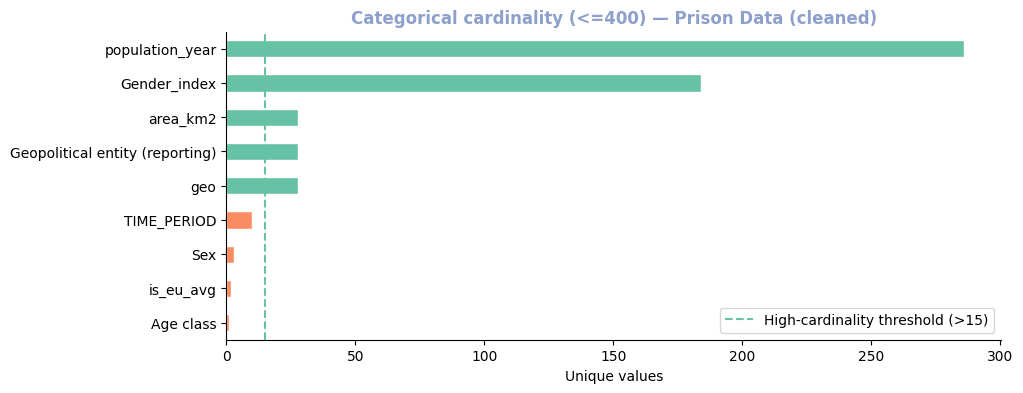

HIGH-CARDINALITY features (excluded from chart):
    'PerHundred': 769 unique values — needs grouping/target encoding
    'Total': 774 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data (cleaned)):
  'Age class' (1 values): ['Total']

  'is_eu_avg' (2 values): ['0', '1']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'TIME_PERIOD' (10 values): ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (28 values): ['AUT', 'BEL', 'BGR', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'EU', 'FIN', 'FRA', 'GRC', 'HRV', 'HUN', 'IRL', 'ITA', 'LTU', 'LUX', 'LVA', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'SWE']

  'Geopolitical entity (reporting)' (28 values): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'EU Average', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Ro

In [38]:
inspect_categorical(prison_data_with_eu, "Prison Data (cleaned)")

In [39]:
# Save the cleaned dataset in Data to export folder
prison_data_with_eu.to_csv('../data/Data to export/cleaned_prison_data.csv', index=False)

In [40]:
# After manuel input of missing values reload the dataset with the new values
# DON'T RUN THE PREVIOUS CELLS
final_prison_data = pd.read_csv('../data/Data to export/final_prison_data.csv')
final_prison_data.columns = final_prison_data.columns.str.strip()

In [41]:
# Parameters
TIME_PERIOD = 2017          # Anno disponibile: 2014-2023
SEX         = 'Total'     # Opzioni: 'Females', 'Males', 'Total'

# Validazione parametri
assert TIME_PERIOD in final_prison_data['TIME_PERIOD'].unique(), \
    f"Anno non valido. Disponibili: {sorted(final_prison_data['TIME_PERIOD'].unique())}"
assert SEX in final_prison_data['Sex'].unique(), \
    f"Sesso non valido. Opzioni: {final_prison_data['Sex'].unique().tolist()}"

filtered = final_prison_data[
    (final_prison_data['TIME_PERIOD'] == TIME_PERIOD) &
    (final_prison_data['Sex']         == SEX)         
]
# Aggrega per paese
agg = (
    filtered.groupby('Geopolitical entity (reporting)')['PerHundred']
    .mean()
    .reset_index()
)
agg.columns = ['country', 'value']
agg['value'] = agg['value'].round(1)
agg['iso3']  = agg['country'].map(country_codes)
agg = agg[agg['iso3'].notna()].copy()

print(f"Paesi con dati disponibili: {len(agg)}")
print(agg.sort_values('value', ascending=False).to_string(index=False))

# Mappa statica
fig = px.choropleth(
    agg,
    locations='iso3',
    color='value',
    hover_name='country',
    hover_data={'value': ':.1f', 'iso3': False},
    color_continuous_scale='YlOrRd',
    labels={'value': 'Per 100k abitanti'},
    title=f'Detenuti per 100.000 abitanti — Europa'
          f'<br><sup>Anno: {TIME_PERIOD} | Genere: {SEX}</sup>',
    scope='europe',
)
fig.update_geos(
    visible=True, resolution=50,
    showcoastlines=True, coastlinecolor='#444',
    showland=True,  landcolor='#2d2d3e',
    showocean=True, oceancolor='#1a1a2e',
    showlakes=True, lakecolor='#1a1a2e',
    showframe=False,
    projection_type='natural earth',
    lataxis_range=[34, 72], lonaxis_range=[-25, 45],
    bgcolor='#1a1a2e',
)
fig.update_layout(
    title_font=dict(size=18, color='white'),
    paper_bgcolor='#1a1a2e',
    font=dict(color='white'),
    coloraxis_colorbar=dict(
        title=dict(text='Per 100k abitanti', font=dict(color='white', size=12)),
        tickfont=dict(color='white'),
        bgcolor='rgba(30,30,50,0.8)',
        bordercolor='#555', borderwidth=1,
        len=0.7, thickness=15,
    ),
    margin=dict(l=0, r=0, t=80, b=0),
    height=650,
)
# Disabilita interattività — mappa statica
fig.show(config={
    'staticPlot': False,       # nessun zoom/pan/hover
    'displayModeBar': False,  # nasconde la toolbar
})

Paesi con dati disponibili: 27
    country  value iso3
  Lithuania  232.1  LTU
    Czechia  209.2  CZE
    Estonia  206.7  EST
     Poland  196.1  POL
     Latvia  193.8  LVA
   Slovakia  184.4  SVK
    Hungary  178.3  HUN
   Portugal  130.5  PRT
      Malta  126.5  MLT
      Spain  126.3  ESP
    Romania  119.7  ROU
 Luxembourg  114.7  LUX
     France  103.1  FRA
   Bulgaria  102.7  BGR
    Austria  100.6  AUT
      Italy   98.4  ITA
     Greece   93.1  GRC
    Belgium   92.0  BEL
    Croatia   78.9  HRV
    Germany   77.7  DEU
    Ireland   76.2  IRL
Netherlands   63.5  NLD
   Slovenia   63.4  SVN
    Denmark   59.3  DNK
     Sweden   56.8  SWE
    Finland   56.0  FIN
     Cyprus   47.2  CYP


-----

In [42]:
# --- ANALYSIS: Female adult prisoners vs Gender Index ---

# Filter: females, adults only, exclude EU Average
prison_female = final_prison_data[
    (final_prison_data['Sex'] == 'Females') &
    (final_prison_data['Geopolitical entity (reporting)'] != 'EU Average')
].copy()

# Quick check
print(f"Rows: {len(prison_female)}")
print(f"Countries: {prison_female['Geopolitical entity (reporting)'].nunique()}")
print(f"Years: {sorted(prison_female['TIME_PERIOD'].unique())}")
print(f"\nSample:")
print(prison_female[['Geopolitical entity (reporting)', 'TIME_PERIOD', 'PerHundred', 'Gender_index']].head(10))
print(f"\nMissing values:\n{prison_female[['PerHundred', 'Gender_index']].isna().sum()}")

Rows: 270
Countries: 27
Years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Sample:
   Geopolitical entity (reporting)  TIME_PERIOD  PerHundred  Gender_index
0                          Austria         2022        6.62        0.7810
3                          Austria         2021        5.88        0.7770
6                          Austria         2020        6.21        0.7440
9                          Austria         2023        6.72        0.7400
12                         Austria         2015        5.76        0.7330
15                         Austria         2019        6.82        0.7310
18                         Austria         2014        5.93        0.7266
21                         Austria         2018        6.37        0.7180
24                         Austria         2016        5.63        0.7160
27                         Austria         2017        5.89

In [43]:
from scipy import stats

# --- Rebuild prison_female using Age class == 'Total' from total_values ---

prison_female = final_prison_data[
    (final_prison_data['Sex'] == 'Females') &
    (final_prison_data['Age class'] == 'Total') &
    (final_prison_data['Geopolitical entity (reporting)'] != 'EU Average')
].copy()

prison_all = final_prison_data[
    (final_prison_data['Sex'] == 'Total') &
    (final_prison_data['Age class'] == 'Total') &
    (final_prison_data['Geopolitical entity (reporting)'] != 'EU Average')
][['Geopolitical entity (reporting)', 'TIME_PERIOD', 'Total']].rename(columns={'Total': 'Total_all'})

prison_female = prison_female.merge(
    prison_all,
    on=['Geopolitical entity (reporting)', 'TIME_PERIOD'],
    how='left'
)

prison_female['Female_pct'] = (prison_female['Total'] / prison_female['Total_all'] * 100).round(2)

print(f"Rows: {len(prison_female)}, Missing Female_pct: {prison_female['Female_pct'].isna().sum()}")
print(prison_female[['Geopolitical entity (reporting)', 'TIME_PERIOD', 'PerHundred', 'Female_pct', 'Gender_index']].head(10))

# --- CORRELATIONS ---
clean = prison_female.dropna(subset=['Gender_index', 'PerHundred', 'Female_pct'])

r1, p1    = stats.pearsonr(clean['Gender_index'], clean['PerHundred'])
rho1, p1s = stats.spearmanr(clean['Gender_index'], clean['PerHundred'])

r2, p2    = stats.pearsonr(clean['Gender_index'], clean['Female_pct'])
rho2, p2s = stats.spearmanr(clean['Gender_index'], clean['Female_pct'])

print("\n=== CORRELATIONS ===")
print(f"\nGender Index vs PerHundred (female prisoners per 100k):")
print(f"  Pearson  r = {r1:.3f}  (p = {p1:.4f})")
print(f"  Spearman r = {rho1:.3f}  (p = {p1s:.4f})")

print(f"\nGender Index vs Female % of total prisoners:")
print(f"  Pearson  r = {r2:.3f}  (p = {p2:.4f})")
print(f"  Spearman r = {rho2:.3f}  (p = {p2s:.4f})")

Rows: 270, Missing Female_pct: 0
  Geopolitical entity (reporting)  TIME_PERIOD  PerHundred  Female_pct  \
0                         Austria         2022        6.62        6.66   
1                         Austria         2021        5.88        6.25   
2                         Austria         2020        6.21        6.53   
3                         Austria         2023        6.72        6.76   
4                         Austria         2015        5.76        5.75   
5                         Austria         2019        6.82        6.68   
6                         Austria         2014        5.93        5.83   
7                         Austria         2018        6.37        6.14   
8                         Austria         2016        5.63        5.71   
9                         Austria         2017        5.89        5.85   

   Gender_index  
0        0.7810  
1        0.7770  
2        0.7440  
3        0.7400  
4        0.7330  
5        0.7310  
6        0.7266  
7       

## Key finding: correlations

The analysis tests two distinct measures of female incarceration against the WEF Gender Gap Index across 27 EU countries over the period 2014–2023.

Female prisoners per 100,000 inhabitants shows a statistically significant negative correlation with the Gender Gap Index (Pearson $r = -0.330$, Spearman $r = -0.362$, $p = 0.0000$ for both). The consistency between the two coefficients — one assuming linearity, one not — strengthens the finding: countries with higher gender equality tend to imprison fewer women relative to their population, and this relationship is not driven by outliers or a particular distributional shape.

Female share of total prisoners tells a starkly different story. Both Pearson ($r = -0.045, p = 0.4568$) and Spearman ($r = -0.097, p = 0.1121$) correlations are negligible and statistically non-significant. Gender equality, in other words, has no meaningful association with how women are represented within prison populations relative to men.

This divergence between the two metrics is itself a substantive finding. It suggests that as societies become more gender-equal, the absolute rate at which women are imprisoned decreases — but this reduction happens in parallel with a comparable decrease in male incarceration, leaving the internal gender ratio of prisons largely unchanged. The driver appears to be a broader systemic effect on criminality and criminal justice, rather than a gender-specific one.

In [44]:
# Use average per country per year (already one row per country-year in prison_female)
map_data = prison_female.dropna(subset=['Female_pct']).copy()
map_data['TIME_PERIOD'] = map_data['TIME_PERIOD'].astype(int)

fig = px.choropleth(
    map_data,
    locations='geo',
    color='Female_pct',
    hover_name='Geopolitical entity (reporting)',
    hover_data={'Female_pct': ':.2f', 'geo': False},
    animation_frame='TIME_PERIOD',
    category_orders={
        'TIME_PERIOD': sorted(map_data['TIME_PERIOD'].unique())
    },
    color_continuous_scale='YlOrRd',
    labels={'Female_pct': 'Female % of prisoners'},
    title='Female Share of Prison Population (%) — Europe (2014–2023)',
    scope='europe',
)
fig.update_geos(
    visible=True, resolution=50,
    showcoastlines=True, coastlinecolor='#444',
    showland=True,  landcolor='#2d2d3e',
    showocean=True, oceancolor='#1a1a2e',
    showlakes=True, lakecolor='#1a1a2e',
    showframe=False,
    projection_type='natural earth',
    lataxis_range=[34, 72], lonaxis_range=[-25, 45],
    bgcolor='#1a1a2e',
)
fig.update_layout(
    title_font=dict(size=16, color='white'),
    paper_bgcolor='#1a1a2e',
    font=dict(color='white'),
    coloraxis_colorbar=dict(
        title=dict(text='Female %', font=dict(color='white', size=12)),
        tickfont=dict(color='white'),
        bgcolor='rgba(30,30,50,0.8)',
        bordercolor='#555', borderwidth=1,
        len=0.7, thickness=15,
    ),
    margin=dict(l=0, r=0, t=60, b=0),
    height=650,
)
# Slow down animation
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 800
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 400

fig.show()

In [45]:
# --- SUMMARY STATS FOR NARRATIVE ---

clean = prison_female.dropna(subset=['Gender_index', 'PerHundred', 'Female_pct']).copy()

# 1. EU average Female_pct per year
eu_pct_by_year = clean.groupby('TIME_PERIOD')['Female_pct'].mean().round(2)
print("=== EU Average Female % by year ===")
print(eu_pct_by_year)

# 2. Overall EU average Female_pct (2014-2023)
print(f"\nOverall EU average Female %: {clean['Female_pct'].mean():.2f}%")

# 3. Country averages (2014-2023) — top and bottom 5 by Female_pct
country_avg = clean.groupby('Geopolitical entity (reporting)')[['Female_pct', 'PerHundred', 'Gender_index']].mean().round(2)
print("\n=== Top 5 countries by Female % (avg 2014-2023) ===")
print(country_avg.sort_values('Female_pct', ascending=False).head(5))
print("\n=== Bottom 5 countries by Female % (avg 2014-2023) ===")
print(country_avg.sort_values('Female_pct', ascending=False).tail(5))

# 4. Country averages — top and bottom 5 by PerHundred
print("\n=== Top 5 countries by PerHundred (avg 2014-2023) ===")
print(country_avg.sort_values('PerHundred', ascending=False).head(5))
print("\n=== Bottom 5 countries by PerHundred (avg 2014-2023) ===")
print(country_avg.sort_values('PerHundred', ascending=False).tail(5))

# 5. Change from 2014 to 2023 at EU level
for metric in ['Female_pct', 'PerHundred']:
    val_2014 = clean[clean['TIME_PERIOD'] == 2014][metric].mean()
    val_2023 = clean[clean['TIME_PERIOD'] == 2023][metric].mean()
    print(f"\n{metric}: 2014 avg = {val_2014:.2f} → 2023 avg = {val_2023:.2f} (Δ = {val_2023 - val_2014:+.2f})")

=== EU Average Female % by year ===
TIME_PERIOD
2014    5.34
2015    5.43
2016    5.62
2017    6.12
2018    5.78
2019    5.75
2020    5.58
2021    5.82
2022    5.76
2023    5.79
Name: Female_pct, dtype: float64

Overall EU average Female %: 5.70%

=== Top 5 countries by Female % (avg 2014-2023) ===
                                 Female_pct  PerHundred  Gender_index
Geopolitical entity (reporting)                                      
Malta                                  8.13       10.52          0.69
Latvia                                 7.97       15.18          0.77
Czechia                                7.72       14.75          0.69
Finland                                7.60        4.10          0.84
Hungary                                7.53       13.63          0.68

=== Bottom 5 countries by Female % (avg 2014-2023) ===
                                 Female_pct  PerHundred  Gender_index
Geopolitical entity (reporting)                                      
Denmark       